# Inspect Stage 1 Climate Output Files (.npz & .pkl)

This notebook demonstrates how to load, explore, and plot the contents of the Stage 1 climate outputs generated by the Aurora climate pipeline:
1. **`.npz` files** (`climate_XX.npz`) containing the converged $P$-$T$ profile array and a comprehensive JSON metadata block with quality control diagnostics.
2. **`.pkl` files** (`climate_XX_case.pkl`) containing the pickled in-memory `picaso.justdoit.inputs` case object with full chemistry details (species mole fractions).

## Setup & Imports
First, we make sure to insert `roadrunner_egp` into `sys.path` and import `roadrunner.config` to configure environmental variables required by PICASO before unpickling case objects.

In [1]:
import sys
import json
import pickle
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Add roadrunner path to environment to import configuration correctly
sys.path.insert(0, "../..")
import roadrunner.config
import picaso.justdoit as jdi

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

## 1. Locate the files

In [2]:
SAMPLE_DIR = Path("../sample_outputs")
npz_path = SAMPLE_DIR / "climate_00.npz"
pkl_path = SAMPLE_DIR / "climate_00_case.pkl"

print(f"NPZ file exists: {npz_path.exists()} ({npz_path})")
print(f"PKL file exists: {pkl_path.exists()} ({pkl_path})")

NPZ file exists: True (../sample_outputs/climate_00.npz)
PKL file exists: True (../sample_outputs/climate_00_case.pkl)


---
## 2. Reading the `.npz` File

The `.npz` file contains:
- `pressure`: 1D array of atmospheric pressure levels (bar)
- `temperature`: 1D array of converged temperatures (K)
- `metadata_json`: string containing JSON-serialized metadata, including convergence flags and run settings.

In [3]:
# Load NPZ file
npz_data = np.load(npz_path, allow_pickle=True)
print("NPZ keys:", list(npz_data.keys()))

NPZ keys: ['pressure', 'temperature', 'metadata_json']


### Parse Metadata & Diagnostics
We load the `metadata_json` string and print out the core metadata entries.

In [4]:
meta = json.loads(str(npz_data["metadata_json"]))
print("Metadata keys:", list(meta.keys()))
print(f"Climate Group Index: {meta.get('climate_group_index')}")
print(f"Selected Opacity HDF5: {meta.get('selected_ck_file')}")
print(f"Semi-major axis (AU):  {meta.get('semi_major_au')}")

Metadata keys: ['climate_group_index', 'selected_ck_file', 'cahoy_planet_type', 'cahoy_metallicity_label', 'semi_major_au', 'cahoy_cloud_note', 'diagnostics']
Climate Group Index: 0
Selected Opacity HDF5: /home/u11/danielxinhuang/Documents/aurora/picaso4_reference/opacities/sonora_2121grid_feh0.0_co0.27.hdf5
Semi-major axis (AU):  0.2796803377736613


### Quality Control (QC) Diagnostics
The `diagnostics` dictionary nested inside the metadata contains information about the convergence process and physics parameters.

In [5]:
diag = meta.get("diagnostics", {})
print("Diagnostics keys:", list(diag.keys()))
print(f"Climate converged: {diag.get('climate_converged') == 1}")
print(f"RCB guess index:   {diag.get('rcb_guess')}")
print(f"moistgrad flag:    {diag.get('moistgrad')}")

Diagnostics keys: ['selected_ck_file', 'climate_opacity_method', 'initial_pressure', 'initial_temp_guess', 'rcb_guess', 'nstr', 'rfacv', 'rfaci', 'moistgrad', 'schema_warnings', 'dtdp', 'qc_dtdp', 'fnet_irfnet', 'flux_balance', 'spectrum_output', 'pressure', 'temperature', 'climate_converged', 'qc_adiabat', 'qc_adiabat_pressure', 'qc_brightness_temperature', 'qc_brightness_wavelength']
Climate converged: True
RCB guess index:   54
moistgrad flag:    False


### Plot converged P-T profile & flux balance
We can plot the converged pressure-temperature profile directly from the array keys, along with the internal/radiative net flux balance profile from diagnostics.

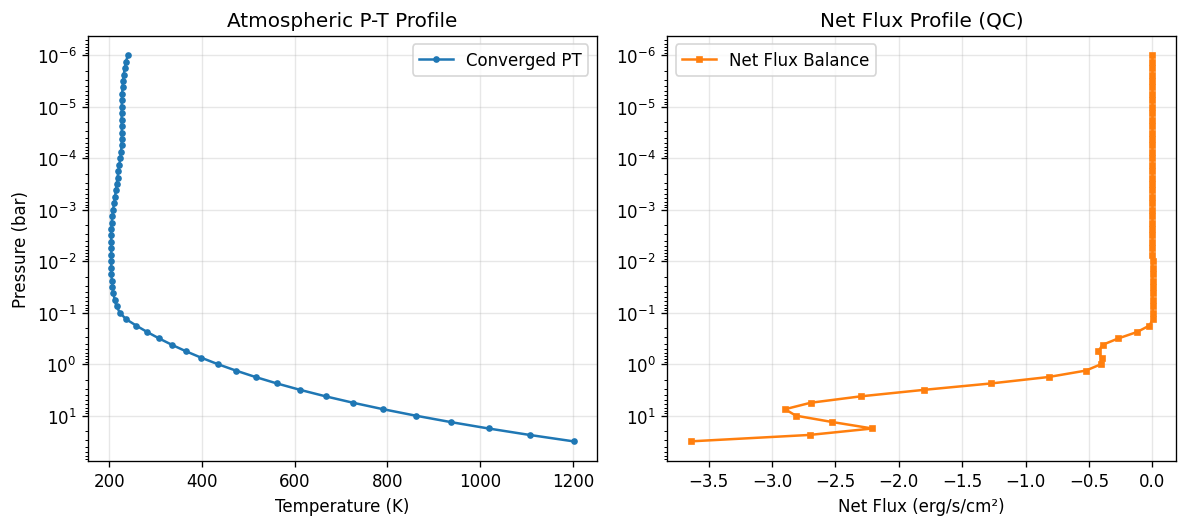

In [6]:
P = npz_data["pressure"]
T = npz_data["temperature"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# Panel 1: PT Profile
axes[0].plot(T, P, "o-", ms=3, label="Converged PT")
axes[0].set_yscale("log")
axes[0].invert_yaxis()
axes[0].set_xlabel("Temperature (K)")
axes[0].set_ylabel("Pressure (bar)")
axes[0].set_title("Atmospheric P-T Profile")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Panel 2: Net Flux Balance Profile (QC)
if "fnet_irfnet" in diag:
    fnet = np.array(diag["fnet_irfnet"])
    # fnet typically corresponds to levels or layers depending on the solver format
    axes[1].plot(fnet, P[:len(fnet)], "s-", ms=3, color="C1", label="Net Flux Balance")
    axes[1].set_yscale("log")
    axes[1].invert_yaxis()
    axes[1].set_xlabel("Net Flux (erg/s/cm²)")
    axes[1].set_title("Net Flux Profile (QC)")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

plt.tight_layout()
plt.show()

---
## 3. Reading the `.pkl` File (PICASO inputs object)

The pickle file contains the serialized PICASO `inputs` object. This contains the host star characteristics, planet orbital spacing, opacity database connections, and full chemical profile info.

In [7]:
with open(pkl_path, "rb") as f:
    case = pickle.load(f)

print("Type of pickled object:", type(case))
print("Inner inputs dictionaries:", list(case.inputs.keys()))

Type of pickled object: <class 'picaso.justdoit.inputs'>
Inner inputs dictionaries: ['version', 'calculation', 'phase', 'planet', 'climate', 'star', 'atmosphere', 'clouds', 'approx', 'disco', 'opacities', 'test_mode', 'phase_angle', 'surface_reflect', 'hard_surface']


### Inspect Chemical Species & Abundances
The `inputs['atmosphere']['profile']` dictionary contains the volume mixing ratio of all chemical species at every vertical pressure level.

In [8]:
profile = case.inputs["atmosphere"]["profile"]
species_keys = [k for k in profile.keys() if k not in ("pressure", "temperature", "index")]
print(f"Found {len(species_keys)} chemical species:")
print(species_keys)

Found 50 chemical species:
['e-', 'H2', 'H', 'H+', 'H-', 'H2-', 'H2+', 'H3+', 'He', 'H2O', 'CH4', 'CO', 'NH3', 'N2', 'PH3', 'H2S', 'TiO', 'VO', 'Fe', 'FeH', 'CrH', 'Na', 'K', 'Rb', 'Cs', 'CO2', 'HCN', 'C2H2', 'C2H4', 'C2H6', 'SiO', 'MgH', 'OCS', 'Li', 'LiOH', 'LiH', 'LiCl', 'OH', 'C-gr', 'Li+', 'LiF', 'C', 'O', 'Mg', 'Mg+', 'Si', 'Fe+', 'Ti', 'Ti+', 'C+']


### Plot Chemistry Abundance Profiles
We can plot the mixing ratios for the primary chemical species to visualize the atmospheric chemistry structure.

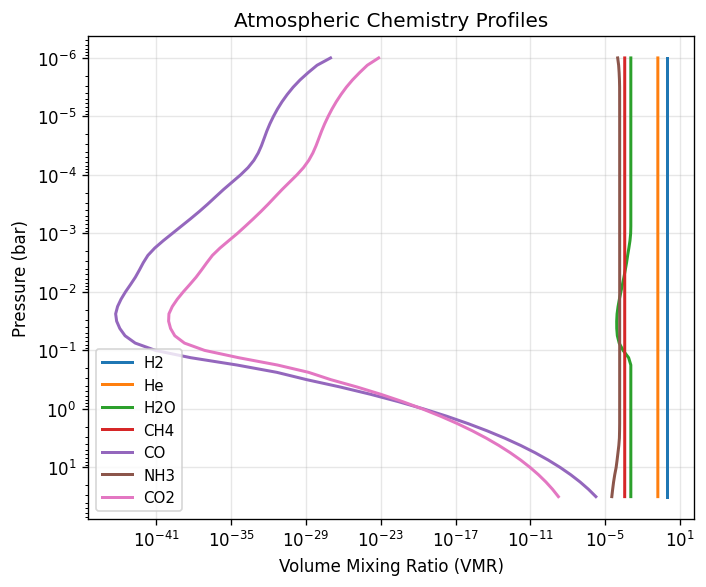

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))

major_species = ["H2", "He", "H2O", "CH4", "CO", "NH3", "CO2"]
cmap = plt.cm.tab10

for i, sp in enumerate(major_species):
    if sp in profile:
        vmr = np.array(profile[sp])
        if vmr.max() > 1e-12:   # Only plot if species is present above detection
            ax.plot(vmr, P, label=sp, lw=1.8, color=cmap(i))

ax.set_xscale("log")
ax.set_yscale("log")
ax.invert_yaxis()
ax.set_xlabel("Volume Mixing Ratio (VMR)")
ax.set_ylabel("Pressure (bar)")
ax.set_title("Atmospheric Chemistry Profiles")
ax.legend(loc="lower left", fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
import pandas as pd
print(pd.__version__)

3.0.3
